# Statistical Analysis of Student Academic Performance

## Objective

The objective of this study is to examine the influence of gender and parental educational attainment on student academic performance in Mathematics and Language subjects. Statistical techniques including independent-samples t-tests, Cohen's d effect size analysis, one-way ANOVA, and Tukey's HSD post-hoc tests were applied to identify significant differences between groups.

## Research Questions and Hypotheses

### RQ1
Does gender significantly influence Mathematics performance?

H₀: There is no significant difference in Mathematics scores between male and female students.

H₁: There is a significant difference in Mathematics scores between male and female students.

### RQ2
Does gender significantly influence Language performance?

H₀: There is no significant difference in Language scores between male and female students.

H₁: There is a significant difference in Language scores between male and female students.

### RQ3
Does parental educational attainment significantly influence Mathematics performance?

H₀: Mean Mathematics scores are equal across all parental education groups.

H₁: At least one parental education group has a different mean Mathematics score.

### RQ4
Does parental educational attainment significantly influence Language performance?

H₀: Mean Language scores are equal across all parental education groups.

H₁: At least one parental education group has a different mean Language score.


 

## Dataset Overview

The dataset contains student performance records including gender, parental educational attainment, subject, and examination score. The data were analyzed to investigate the influence of demographic and family-background factors on academic achievement.

## Dataset Summary

The dataset contains 972 student performance records and 5 variables: student_id, gender, parental educational attainment, subject, and score.

The dataset consists of one numerical variable (score) and four categorical or identifier variables (student_id, gender, parental educational attainment, and subject).

No missing values were detected in the dataset. Therefore, no imputation or additional data-cleaning procedures were required prior to statistical analysis.

In [1]:
import pandas as pd
import numpy as np

In [2]:


df = pd.read_csv(
    "../input_data/Scores.csv",
    sep=";",
    decimal=","
)

df.head()

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23.0
1,2,id_001,female,high school,language,40.0
2,3,id_002,female,high school,math,68.0
3,4,id_002,female,high school,language,80.5
4,5,id_003,male,high school,math,82.0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   972 non-null    int64  
 1   student_id                   972 non-null    str    
 2   gender                       972 non-null    str    
 3   parental.level.of.education  972 non-null    str    
 4   subject                      972 non-null    str    
 5   score                        972 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 45.7 KB


Unnamed: 0                     0
student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64

In [4]:
df.shape

(972, 6)

In [5]:
df.columns

Index(['Unnamed: 0', 'student_id', 'gender', 'parental.level.of.education',
       'subject', 'score'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   972 non-null    int64  
 1   student_id                   972 non-null    str    
 2   gender                       972 non-null    str    
 3   parental.level.of.education  972 non-null    str    
 4   subject                      972 non-null    str    
 5   score                        972 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 45.7 KB


In [7]:
#cleaning the dataset
df = df.drop(columns=['Unnamed: 0'])

df.head()

,student_id,gender,parental.level.of.education,subject,score
0,id_001,female,high school,math,23.0
1,id_001,female,high school,language,40.0
2,id_002,female,high school,math,68.0
3,id_002,female,high school,language,80.5
4,id_003,male,high school,math,82.0


In [8]:
df['subject'].value_counts()

subject
math        486
language    486
Name: count, dtype: int64

In [9]:
df['gender'].value_counts()

gender
female    490
male      482
Name: count, dtype: int64

In [10]:
df['parental.level.of.education'].value_counts()

parental.level.of.education
associate's degree    354
high school           312
bachelor's degree     188
master's degree       118
Name: count, dtype: int64

In [11]:
#math dataset
math_df = df[df['subject'] == 'math']

math_df.head()

,student_id,gender,parental.level.of.education,subject,score
0,id_001,female,high school,math,23.0
2,id_002,female,high school,math,68.0
4,id_003,male,high school,math,82.0
6,id_004,female,high school,math,58.0
8,id_005,female,high school,math,60.0


In [12]:
#language dataset
language_df = df[df['subject'] == 'language']

language_df.head()

,student_id,gender,parental.level.of.education,subject,score
1,id_001,female,high school,language,40.0
3,id_002,female,high school,language,80.5
5,id_003,male,high school,language,81.0
7,id_004,female,high school,language,60.5
9,id_005,female,high school,language,69.0


In [13]:
#math statistics by Gender
math_df.groupby('gender')['score'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
gender,,,,,,
female,245,63.857143,64.0,15.261921,23.0,100.0
male,241,68.946058,70.0,14.425137,30.0,100.0


In [14]:
#language statistics by Gender
language_df.groupby('gender')['score'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
gender,,,,,,
female,245,73.004082,73.0,14.012508,29.5,100.0
male,241,64.931535,65.5,13.752291,19.5,100.0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

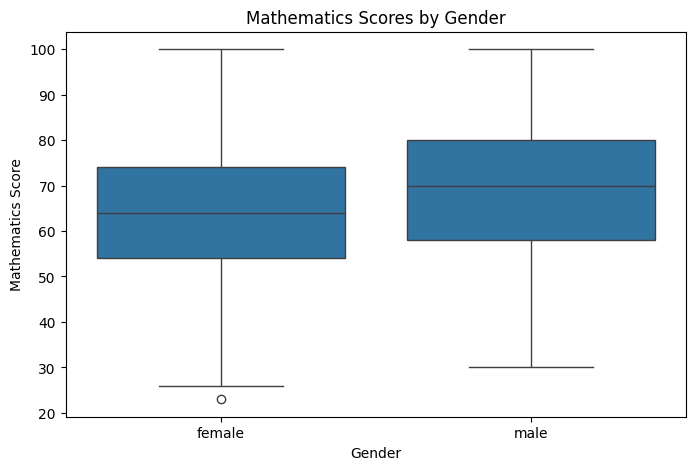

In [16]:
#math boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=math_df,
    x='gender',
    y='score'
)

plt.title('Mathematics Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Mathematics Score')

plt.show()

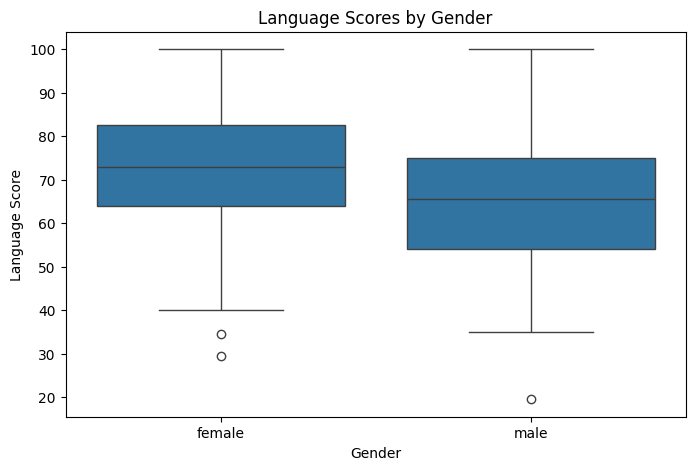

In [17]:
#language boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=language_df,
    x='gender',
    y='score'
)

plt.title('Language Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Language Score')

plt.show()

In [18]:
from scipy.stats import ttest_ind

In [19]:
#math T-test
female_math = math_df[
    math_df['gender'] == 'female'
]['score']

male_math = math_df[
    math_df['gender'] == 'male'
]['score']

t_stat, p_value = ttest_ind(
    female_math,
    male_math,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.7782415760861223
P-value: 0.00017765367995423856


In [20]:
#language T-test
female_language = language_df[
    language_df['gender'] == 'female'
]['score']

male_language = language_df[
    language_df['gender'] == 'male'
]['score']

t_stat, p_value = ttest_ind(
    female_language,
    male_language,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 6.409643311669151
P-value: 3.466762335140578e-10


In [21]:
from scipy.stats import shapiro

female_result = shapiro(female_math)
male_result = shapiro(male_math)

print("Female Math:")
print(female_result)

print("\nMale Math:")
print(male_result)

Female Math:
ShapiroResult(statistic=np.float64(0.9943932635152392), pvalue=np.float64(0.5009746564906498))

Male Math:
ShapiroResult(statistic=np.float64(0.9884607427338196), pvalue=np.float64(0.05047678317999748))


In [22]:
female_language_result = shapiro(female_language)
male_language_result = shapiro(male_language)

print("Female Language:")
print(female_language_result)

print("\nMale Language:")
print(male_language_result)

Female Language:
ShapiroResult(statistic=np.float64(0.9898792607826029), pvalue=np.float64(0.08529245941686132))

Male Language:
ShapiroResult(statistic=np.float64(0.9909146507048567), pvalue=np.float64(0.13896521428548897))


In [23]:
from scipy.stats import levene

levene_math = levene(female_math, male_math)

print("Math Levene Test:")
print(levene_math)

Math Levene Test:
LeveneResult(statistic=np.float64(0.006027226933929371), pvalue=np.float64(0.938150311199935))


In [24]:
levene_language = levene(female_language, male_language)

print("Language Levene Test:")
print(levene_language)

Language Levene Test:
LeveneResult(statistic=np.float64(0.15959812692149067), pvalue=np.float64(0.689703007954745))


In [25]:
import numpy as np

mean_diff = male_math.mean() - female_math.mean()

pooled_sd = np.sqrt(
    ((male_math.std()**2) + (female_math.std()**2)) / 2
)

cohens_d_math = mean_diff / pooled_sd

print("Cohen's d (Math):", cohens_d_math)

Cohen's d (Math): 0.3427011788958532


In [26]:
mean_diff = female_language.mean() - male_language.mean()

pooled_sd = np.sqrt(
    ((female_language.std()**2) + (male_language.std()**2)) / 2
)

cohens_d_language = mean_diff / pooled_sd

print("Cohen's d (Language):", cohens_d_language)

Cohen's d (Language): 0.5814694918117581


In [27]:
#part 2 (4 groups)

In [28]:
math_df.groupby('parental.level.of.education')['score'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
parental.level.of.education,,,,
associate's degree,177,67.813559,66.0,15.244382
bachelor's degree,94,68.436170,67.0,15.048708
high school,156,62.243590,63.0,14.036989
master's degree,59,69.745763,73.0,15.153915


In [29]:
language_df.groupby('parental.level.of.education')['score'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
parental.level.of.education,,,,
associate's degree,177,70.022599,72.0,14.214951
bachelor's degree,94,72.058511,73.0,14.267200
high school,156,63.532051,65.0,13.398685
master's degree,59,75.525424,76.0,13.554304


In [30]:
#math ANOVA
from scipy.stats import f_oneway

math_highschool = math_df[
    math_df['parental.level.of.education'] == 'high school'
]['score']

math_associate = math_df[
    math_df['parental.level.of.education'] == "associate's degree"
]['score']

math_bachelor = math_df[
    math_df['parental.level.of.education'] == "bachelor's degree"
]['score']

math_master = math_df[
    math_df['parental.level.of.education'] == "master's degree"
]['score']

anova_math = f_oneway(
    math_highschool,
    math_associate,
    math_bachelor,
    math_master
)

print(anova_math)

F_onewayResult(statistic=np.float64(6.222926244479987), pvalue=np.float64(0.0003750888011045912))


In [31]:
#language ANOVA
language_highschool = language_df[
    language_df['parental.level.of.education'] == 'high school'
]['score']

language_associate = language_df[
    language_df['parental.level.of.education'] == "associate's degree"
]['score']

language_bachelor = language_df[
    language_df['parental.level.of.education'] == "bachelor's degree"
]['score']

language_master = language_df[
    language_df['parental.level.of.education'] == "master's degree"
]['score']

anova_language = f_oneway(
    language_highschool,
    language_associate,
    language_bachelor,
    language_master
)

print(anova_language)

F_onewayResult(statistic=np.float64(14.240589988038185), pvalue=np.float64(6.617863732257674e-09))


In [32]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [33]:
#math tukey
from statsmodels.stats.multicomp import pairwise_tukeyhsd

math_tukey = pairwise_tukeyhsd(
    endog=math_df['score'],
    groups=math_df['parental.level.of.education'],
    alpha=0.05
)

print(math_tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------


In [34]:
#language tukey
language_tukey = pairwise_tukeyhsd(
    endog=language_df['score'],
    groups=language_df['parental.level.of.education'],
    alpha=0.05
)

print(language_tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0359 0.6596  -2.5337  6.6055  False
associate's degree       high school  -6.4905 0.0001 -10.4226 -2.5585   True
associate's degree   master's degree   5.5028 0.0429   0.1202 10.8854   True
 bachelor's degree       high school  -8.5265    0.0 -13.2016 -3.8514   True
 bachelor's degree   master's degree   3.4669 0.4365  -2.4802   9.414  False
       high school   master's degree  11.9934    0.0    6.521 17.4658   True
----------------------------------------------------------------------------


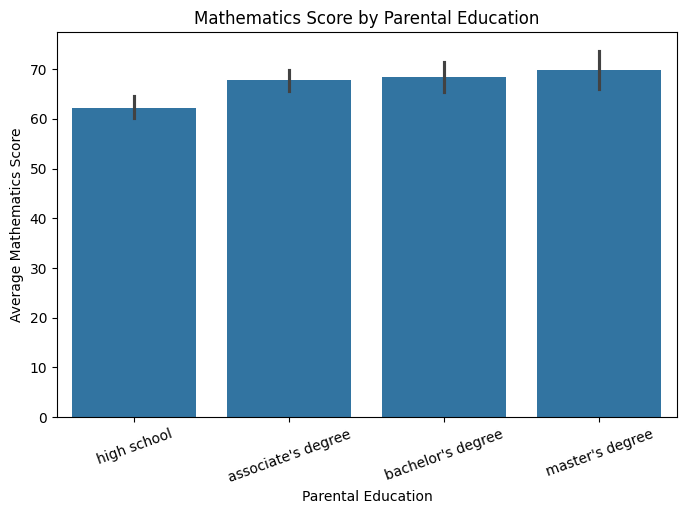

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=math_df,
    x='parental.level.of.education',
    y='score',
    errorbar=('ci', 95)
)

plt.title('Mathematics Score by Parental Education')
plt.xlabel('Parental Education')
plt.ylabel('Average Mathematics Score')

plt.xticks(rotation=20)

plt.show()

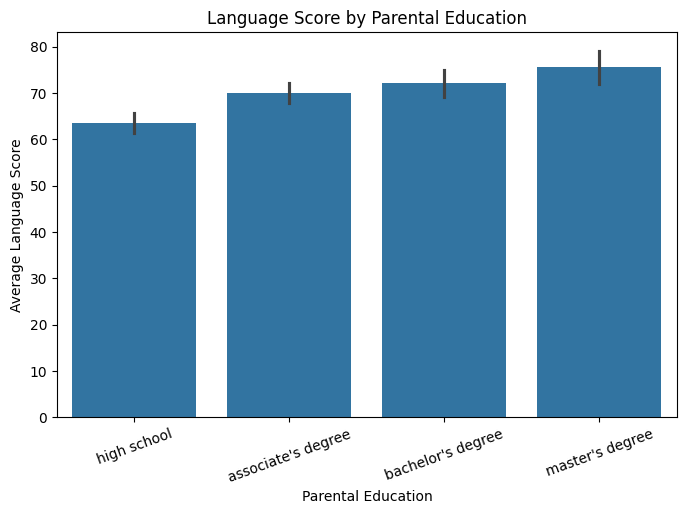

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=language_df,
    x='parental.level.of.education',
    y='score',
    errorbar=('ci', 95)
)

plt.title('Language Score by Parental Education')
plt.xlabel('Parental Education')
plt.ylabel('Average Language Score')

plt.xticks(rotation=20)

plt.show()

In [37]:
print(math_tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------


## Mathematics Achievement and Parental Education

The average Mathematics score increased with parental educational attainment. Students whose parents completed only High School achieved the lowest mean score (M = 62.24), whereas students whose parents held a Master's degree achieved the highest mean score (M = 69.75).

A one-way ANOVA revealed a statistically significant effect of parental education on Mathematics performance, F(3, 482) = 6.22, p < .001.

Tukey's HSD post-hoc analysis showed that students from the High School group scored significantly lower than students from the Associate's, Bachelor's, and Master's degree groups.

These findings suggest that parental educational attainment is positively associated with student Mathematics achievement.

In [38]:
print(language_tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0359 0.6596  -2.5337  6.6055  False
associate's degree       high school  -6.4905 0.0001 -10.4226 -2.5585   True
associate's degree   master's degree   5.5028 0.0429   0.1202 10.8854   True
 bachelor's degree       high school  -8.5265    0.0 -13.2016 -3.8514   True
 bachelor's degree   master's degree   3.4669 0.4365  -2.4802   9.414  False
       high school   master's degree  11.9934    0.0    6.521 17.4658   True
----------------------------------------------------------------------------


## Language Achievement and Parental Education

Language scores showed a clear positive relationship with parental educational attainment. Students whose parents completed only High School achieved the lowest mean Language score (M = 63.53), while students whose parents held a Master's degree achieved the highest mean score (M = 75.53).

A one-way ANOVA demonstrated a significant effect of parental education on Language performance, F(3, 482) = 14.24, p < .001.

Tukey's HSD analysis indicated significant differences between multiple educational groups, particularly between the High School and Master's degree categories.

The results suggest that parental education has a substantial influence on Language achievement and may contribute to differences in academic performance across students.


# Conclusion

This study investigated the influence of gender and parental education on student academic performance in Mathematics and Language subjects.

Independent-samples t-tests revealed significant gender differences in both subjects. Male students achieved significantly higher Mathematics scores than female students (t = -3.78, p < .001), whereas female students achieved significantly higher Language scores than male students (t = 6.41, p < .001).

One-way ANOVA analyses demonstrated that parental education level significantly influenced both Mathematics achievement (F = 6.22, p < .001) and Language achievement (F = 14.24, p < .001).

Post-hoc Tukey HSD tests confirmed that students whose parents completed only High School generally scored lower than students from higher educational groups.

The strongest parental education effect was observed in Language performance, where students with parents holding Master's degrees consistently achieved the highest scores.

Overall, the findings suggest that both gender and parental educational attainment are important factors associated with academic achievement.


# Key Findings

1. Male students performed significantly better in Mathematics.

2. Female students performed significantly better in Language.

3. Students whose parents possessed higher educational qualifications achieved higher Mathematics scores.

4. Students whose parents possessed higher educational qualifications achieved higher Language scores.

5. Parental education demonstrated a stronger influence on Language achievement than on Mathematics achievement, as indicated by a larger ANOVA F-statistic.

6. High School parental education groups consistently demonstrated lower academic performance compared with Bachelor's and Master's degree groups.

7. Students whose parents held Master's degrees consistently achieved the highest average scores across both subjects.